In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [10]:
def filter_data(df, dx, sex, dx_to_include):
    """get raw scores for each question for either CBCL, YSR, TRF
    Args:
        dx: str
        target: str
        development: list
        dx_to_include: list
        df: pd.DataFrame
    returns:
        data (pd.DataFrame)
    """

    # filter dataframe
    df_grouped =df[df[dx].isin(dx_to_include)]
    df_grouped = df_grouped[(df_grouped['Sex'].isin(sex)) & \
                            (df_grouped['Age_round'].isin(np.arange(6,18)))].reset_index(drop=True)

    return df_grouped

def load_data(assessment, dx, dx_to_include, cols_to_filter):
    # get data
    df, questions = raw_scores.get_data(
        assessment=assessment, 
        dx=dx, 
        measure=None,
        cols_to_filter=cols_to_filter, # 'Raw', 'Stnd', 'P'
        )

    # get raw scores
    df_filter = filter_data(
                df=df,      
                dx=dx, 
                sex=['female', 'male'],
                dx_to_include=dx_to_include,
                )

    df_melt = pd.melt(df_filter, value_vars=cols_to_filter, 
            id_vars=[ 'Sex', dx, ]) \
            .rename(columns={'variable': 'score_names', 'value': 'scores'})
    
    return df_melt

def calc_ratios(df, group='DX_Subtype_Name', ratio='Sex', measure='WIAT', scale='P'):
    if group is not None:
        grouped_df = df.groupby(['score_names', group, ratio])['scores'].mean().unstack()
    else:
        grouped_df = df.groupby(['score_names',ratio])['scores'].mean().unstack()
    ratio_vals = df[ratio].unique()
    if len(ratio_vals)==2:
        grouped_df['ratio_m'] = (grouped_df[ratio_vals[0]] / grouped_df[ratio_vals[1]]) * 100
        grouped_df.loc[grouped_df['ratio_m'] < 100.0, 'ratio_m'] *= -1
        grouped_df = grouped_df.reset_index()
        grouped_df['score_names'] = grouped_df['score_names'].str.replace(f'{measure},{measure}_', '').str.replace(f'_{scale}', "")

        grouped_df = grouped_df.dropna().reset_index()
        return grouped_df
    else:
        raise ValueError(f'length of groups in {ratio} does not equal 2')


### Educational Achievement

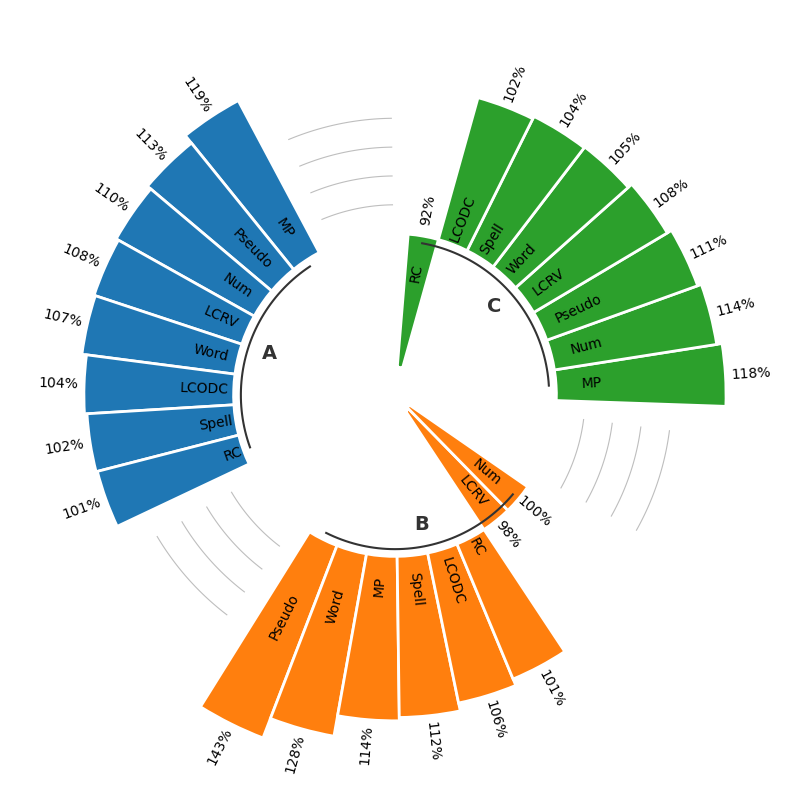

In [18]:
## PLOT ##
measure = 'WIAT'
dx = 'DX_Subtype_Name'
dx_to_include = ['ADHD (Hyperactive Type)', 'ADHD (Inattentive Type)', 'ADHD (Combined Type)']
assessment = 'Child'
scale = 'P'
keys = ['RC', 'Num', 'Pseudo', 'Spell', 'Word', 'LCRV', 'LCODC', 'MP']

# get full keys
cols_to_filter = [f'{measure},{measure}_{key}_{scale}' for key in keys]

# get data for plot
df = load_data(assessment=assessment, 
            dx=dx, 
            dx_to_include=dx_to_include, 
            cols_to_filter=cols_to_filter)

# prepare data for plotting
grouped_df = calc_ratios(df, group=dx, ratio='Sex', measure=measure, scale=scale)

# plot
vis.circular_barplot(df=grouped_df, values='ratio_m', labels='score_names', group=dx)

### Cognitive Assessment

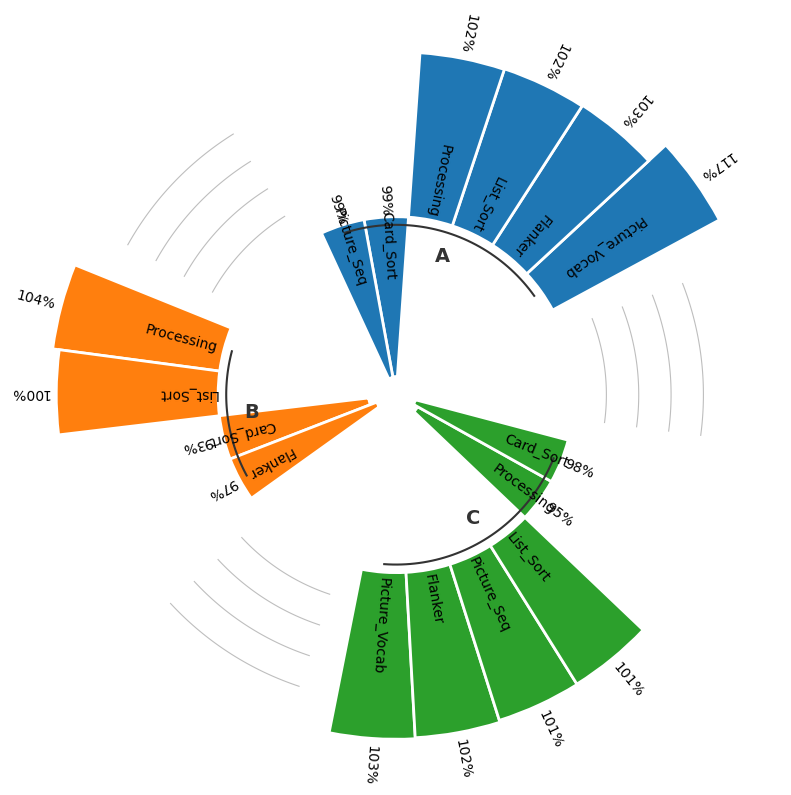

In [24]:
## PLOT ##
measure = 'NIH_final'
scale = 'Stnd'
keys = ['Card_Sort_Age_Corr', 'Flanker_Age_Corr', 'List_Sort_Age_Corr', 
        'Processing_Age_Corr', 'Picture_Vocab_Age_Corr', 'Picture_Seq_Age_Corr']
dx = 'DX_Subtype_Name'
dx_to_include = ['ADHD (Hyperactive Type)', 'ADHD (Inattentive Type)', 'ADHD (Combined Type)']
assessment = 'Child'

# get full keys
cols_to_filter = [f'{measure},NIH_{key}_{scale}' for key in keys]

# get data for plot
df = load_data(
        assessment=assessment, 
            dx=dx, 
            dx_to_include=dx_to_include, 
            cols_to_filter=cols_to_filter
            )
    

grouped_df = calc_ratios(df, group=dx, ratio='Sex', measure=measure, scale=scale)
grouped_df['score_names'] = grouped_df['score_names'].str.replace('NIH_final,NIH_', '').str.replace('_Age_Corr', '')

# plot
vis.circular_barplot(df=grouped_df, values='ratio_m', labels='score_names', group=dx)